 Create a convolutional neural network (CNN), train it to report its performance on 
the testing portion of the dataset, and report its reclassification performance. 95% 
reclassification and 75% testing performance should be achievable without any 
hyperparameter tuning. (Hint: My model, similar to the model in the module notebook, took 
around 10 minutes to train 10 epochs without a GPU.)

In [1]:
#need initial file path of dataset
file_path = r"C:\Users\jbosb\OneDrive\Documents\Hopkins_Studies\Applied_Machine_Learning" #folder path of dataset images

In [2]:
import os #need that for path handling
print(os.path.exists(file_path)) #check that path exists
print(os.listdir(file_path)) #check that path contains files

True
['1-s2.0-S0893608005800231-main.pdf', '1803.01164v2.pdf', '2402.06853v3.pdf', 'appendix_d_calculus.pdf', 'Assignment01_ml.pdf', 'Assignment02_ml.pdf', 'Assignment03_ml.pdf', 'Assignment04_ml.pdf', 'Assignment05_ml.pdf', 'Assignment06_ml.pdf', 'Assignment07_ml.pdf', 'Assignment08_ml.pdf', 'Assignment09_ml.pdf', 'Assignment10_ml.pdf', 'Assignment11_ml.pdf', 'Assignment12_ml.pdf', 'Assignment13_ml.pdf', 'Assignment14_ml.pdf', 'Automatic_differentation.pdf', 'breast_cancer_preprocessed.csv', 'breast_cancer_raw.csv', 'cats_dogs.7z', 'ch11.ipynb', 'clustering_synthetic_dataset.csv', 'creditcard.csv', 'creditcard.csv.zip', 'disinformation.7z', 'GeneratedLabelledFlows.7z', 'heart_dataset.csv', 'mistakes.png', 'mnist.7z', 'seg_pred', 'seg_pred.zip', 'seg_test', 'seg_test.zip', 'seg_train', 'seg_train.zip', 'stack_overflow_data.7z', 'store_data.csv', 'titanic_preprocessed.csv', 'Vanishing_gradient.pdf']


In [3]:
import cv2 #need for handling images


IMGSIZE = (128, 128) 
CNAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] 
X_tr, y_tr, X_ts, y_ts = [], [], [], [] 
for label in CNAMES: 
    path = os.path.join(file_path, 'seg_train', 'seg_train', label)
    for f in sorted([_ for _ in os.listdir(path) if _.lower().endswith('.jpg')]):
        X_tr += [cv2.resize(cv2.imread(os.path.join(path,f)), IMGSIZE)] 
        y_tr += [CNAMES.index(label)] 

for label in CNAMES: 
    path = os.path.join(file_path, 'seg_test', 'seg_test', label)
    for f in sorted([_ for _ in os.listdir(path) if _.lower().endswith('.jpg')]):
        X_ts += [cv2.resize(cv2.imread(os.path.join(path,f)), IMGSIZE)] 
        y_ts += [CNAMES.index(label)]

In [4]:
import numpy as np
X_tr_np = np.array(X_tr)
print(X_tr_np.shape)
y_tr_np = np.array(y_tr)
print(y_tr_np.shape)
X_ts_np = np.array(X_ts)
print(X_ts_np.shape)
y_ts_np = np.array(y_ts)
print(y_ts_np.shape)

(14034, 128, 128, 3)
(14034,)
(3000, 128, 128, 3)
(3000,)


In [5]:
import torch
from torch import nn, optim
import torchvision

if torch.cuda.is_available():
    # CUDA Installation
    print('CUDA Version')
    !nvcc --version
    print()

    # CUDNN Installation
    print(f'CUDNN Version: {torch.backends.cudnn.version()}')
    print(f'Number of CUDA Devices: {torch.cuda.device_count()}')
    print(f'Active CUDA Device: {torch.cuda.current_device()}')
    print(f'Available devices: {torch.cuda.device_count()}, Name: {torch.cuda.get_device_name(0)}')
    print(f'Current CUDA device: {torch.cuda.current_device()}')


CUDA Version

CUDNN Version: 91002
Number of CUDA Devices: 1
Active CUDA Device: 0
Available devices: 1, Name: NVIDIA GeForce RTX 4070 SUPER
Current CUDA device: 0


'nvcc' is not recognized as an internal or external command,
operable program or batch file.


Setup data loaders like module 13, need to define the CNN now

In [6]:
import os
print(os.cpu_count())

16


In [7]:
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as vtransforms
import torchvision.utils as vutils
import torchvision.datasets as dset

IMAGE_SIZE = 128
IMAGE_CHANNELS = 3 #RGB 

HIDDEN_SIZE = 64

BATCH_SIZE = 300 #batch size needed to fit GPU memory

#going to use vtransform to convert image and scale it

training_ds = dset.ImageFolder(root=os.path.join(file_path, 'seg_train', 'seg_train'), transform=vtransforms.Compose([
    vtransforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    vtransforms.ToTensor(), 
    #vtransforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #may revist this later as it will be an issue if I use ReLU activation
]))
testing_ds = dset.ImageFolder(root=os.path.join(file_path, 'seg_test', 'seg_test'), transform=vtransforms.Compose([
    vtransforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    vtransforms.ToTensor(), 
    #vtransforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #may revist this later as it will be an issue if I use ReLU activation
]))

training_dl = DataLoader(training_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) #can use up to 16 cores, will try 4 for now
testing_dl = DataLoader(testing_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

#printing out the tensor shapes to check everythign is okay
for x, y in training_dl:
    print(x.shape)
    print(y.shape)
    break
for x, y in testing_dl:
    print(x.shape)
    print(y.shape)
    break

torch.Size([300, 3, 128, 128])
torch.Size([300])
torch.Size([300, 3, 128, 128])
torch.Size([300])


In [8]:
#need to compute height and weight for fullly connected layer, borrowing these from the notebook
def findConv2dOutShape(_H, _W, _nn, pool=2):
    H = np.floor((_H+2*_nn.padding[0]-_nn.dilation[0]*(_nn.kernel_size[0]-1)-1)/_nn.stride[0]+1)
    W = np.floor((_W+2*_nn.padding[1]-_nn.dilation[1]*(_nn.kernel_size[1]-1)-1)/_nn.stride[1]+1)
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

def findConvTranspose2d(_H, _W, _nn, pool=2):
    H = (_H-1)*_nn.stride[0]-2*_nn.padding[0]+_nn.dilation[0]*(_nn.kernel_size[0]-1)+_nn.output_padding[0]+1
    W = (_W-1)*_nn.stride[1]-2*_nn.padding[1]+_nn.dilation[1]*(_nn.kernel_size[1]-1)+_nn.output_padding[1]+1
    if pool:
        H, W = H/pool, W/pool
    return int(H), int(W)

In [9]:
def init_weights(_m):
    if isinstance(_m, nn.Conv2d) or isinstance(_m, nn.ConvTranspose2d):
        torch.nn.init.normal_(_m.weight, mean=0.0, std=0.02)
    if isinstance(_m, nn.BatchNorm2d):
        torch.nn.init.normal_(_m.weight, mean=1.0, std=0.02)
        _m.bias.data.fill_(0.0)

In [10]:
print(findConv2dOutShape(IMAGE_SIZE, IMAGE_SIZE, nn.Conv2d(IMAGE_CHANNELS, HIDDEN_SIZE, 5)))
print(findConv2dOutShape(12, 12, nn.Conv2d(HIDDEN_SIZE, 2*HIDDEN_SIZE, 5)))

(62, 62)
(4, 4)


In [ ]:
#Build out a CNN
#define last linear layer size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import accuracy_score

LINEAR_SIZE = 2048 #this is the number of features that will be fed into the final linear layer, can adjust as needed
NUMBER_CLASSES = 6

class CNN(nn.Module):
    def __init__ (self, epochs=10, eta=0.001, batch_size=BATCH_SIZE):
        super().__init__()
        self.epochs = epochs #number of epochs to train for
        self.eta = eta #learning rate
        self.batch_size = batch_size #lets be #batch size for training
        self.loss_func = torch.nn.CrossEntropyLoss() #loss function for multi-class classification
        self.model = None #placeholder for the model, will define this as sequential next
    
    def init_layers(self, _K):
        #for model design, convolution -> pooling -> convolution -> pooling -> flatten -> linear (predictor)
        self.model = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS, HIDDEN_SIZE, kernel_size=3, stride=1, padding=1), #using kernel size 3, supposedly good for image data
            nn.ReLU(inplace=True), #activation function, run Inplace to save memory
            nn.MaxPool2d(2), #pooling layer to reduce spatial dimensions, using kernel size 2 to reduce by half
            #nn.BatchNorm2d(HIDDEN_SIZE), #batch normalization, will change this later for some of the other prompts

            #second layer block
            nn.Conv2d(HIDDEN_SIZE, HIDDEN_SIZE*2, kernel_size=3, stride=1, padding=1), #doubling the number of filters in the second layer
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*2), #batch normalization to help with training stability and convergence

            #added in a thrid block to increase the number of features for the linear layer
            nn.Conv2d(HIDDEN_SIZE*2, HIDDEN_SIZE*4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*4), #batch normalization to help with training stability and convergence

            #time to flatten the output for the linear layer, need to calculate the number of features after the convolutional and pooling layers
            #have start_dim at 1 to keep the batch dimension intact
            nn.Flatten(start_dim=1),

            #final layers 
            nn.Linear(16*16 * HIDDEN_SIZE*4, LINEAR_SIZE), #fully connected layer to output class scores, need to calculate the input features based on the output of the convolutional layers
            #nn.BatchNorm1d(LINEAR_SIZE), #batch normalization to help with training stability and convergence
            nn.ReLU(inplace=True),
            nn.Linear(LINEAR_SIZE, NUMBER_CLASSES), #final output layer for classification
        ).to(device) #moving the model to GPU

    def forward(self, _input):
        return self.model(_input)
    
    def predict(self, _X):
        self.eval() #set the model to evaluation mode for prediction
        _X = torch.FloatTensor(_X).to(device, non_blocking=True) #move input to GPU
        assert self.model is not None, "Model layers not initialized. Call init_layers() before prediction."
        with torch.no_grad():
            logits = self.model(_X) #get the raw output from the model
        ypred = torch.argmax(logits, dim=1) #get the predicted class by taking the argmax of the logits
        return ypred.cpu().numpy() #move predictions back to CPU and convert to numpy array for evaluation
    
    def fit(self, _training_dl, info=False):
        import sys
        self.init_layers(NUMBER_CLASSES) #initialize the model layers
        self.train() #set the model to training mode
        #set the optimizer, using Adam for now, can experiment with others like SGD or Rprop
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.eta)

        for e in range(self.epochs):
            #during training
            self.train() #ensure model is in training mode for each epoch
            loss, X_, y_ = None, None, None
            for X_, y_ in _training_dl:
                X_, y_ = X_.to(device, non_blocking=True), y_.to(device, non_blocking=True) #move data to GPU


                optimizer.zero_grad() #zero the gradients before backpropagation
                net_out = self.model(X_) #forward pass through the model
                loss = self.loss_func(net_out, y_) #compute the loss
                loss.backward() #backpropagation to compute gradients
                optimizer.step() #update model parameters based on gradients
            
            if info:
                with torch.no_grad():
                    acc = accuracy_score(y_.tolist(), np.argmax(self.model(X_).cpu(), axis=1).tolist()) #compute accuracy on the last batch of the epoch for monitoring
                sys.stderr.write(f'\rEpoch {e+1:02d}/{self.epochs:02d}, Loss: {loss:<6.2f}, Accuracy: {acc*100:3.2f}%') #print epoch, loss, and accuracy info
                sys.stderr.flush() #flush the output to ensure it prints in real-time
        self.eval() #set the model to evaluation mode at the end of each epoch for validation
        print('\nFinished Training')



In [ ]:
cnn = CNN(epochs=10, eta=0.001, batch_size=BATCH_SIZE).to(device)
cnn.init_layers(NUMBER_CLASSES)
cnn.apply(init_weights)
print(cnn)

In [ ]:
cnn.fit(training_dl, info=True) 

Epoch 7/7, Loss: 0.1711, Accuracy: 0.9530 With initial model, took ~13 min for 7 epochs

Changed to Adam optimization, with Batch normalization, 10 epochs. Took 24 min
Epoch 10/10, Loss: 0.07  , Accuracy: 99.15%

Training Accuracy: 99.42%
Testing Accuracy: 85.60%

Without batch normalization, Adam optimizer, 10 epochs. Took ~8 min
Epoch 10/10, Loss: 0.21  , Accuracy: 94.02%

Training Accuracy: 96.52%
Testing Accuracy: 80.20%


In [ ]:
# Reclassification (training) accuracy
y_train_true, y_train_pred = [], []
for dX, dy in training_dl:
    y_train_true += dy.tolist()
    with torch.no_grad():
        y_train_pred += cnn.predict(dX).tolist()
print(f'Training Accuracy: {accuracy_score(y_train_true, y_train_pred)*100:.2f}%')

# Test accuracy
y_test_true, y_test_pred = [], []
for dX, dy in testing_dl:  # ← testing_dl here
    y_test_true += dy.tolist()
    with torch.no_grad():
        y_test_pred += cnn.predict(dX).tolist()
print(f'Testing Accuracy: {accuracy_score(y_test_true, y_test_pred)*100:.2f}%')

I created this with three con

Part 2: Add regularization and/or drop-out features to your CNN. Report your model's best 
performance. As the performance standard deviation decreases, the model is deemed 
more robust. Why?

Decided to add dropout feature after the linear layer:

Dropout 10%: Epoch 10/10, Loss: 0.32  , Accuracy: 89.32% ~9.5 min
Training Accuracy: 94.27%
Testing Accuracy: 77.23%

Dropout 20%: Epoch 10/10, Loss: 0.22  , Accuracy: 94.44% ~11.5 min
Training Accuracy: 93.62%
Testing Accuracy: 79.97%

Dropout 30%: Epoch 10/10, Loss: 0.29  , Accuracy: 91.88% ~7 min
Training Accuracy: 91.70%
Testing Accuracy: 79.77%

Looks like there is not much improvement in loss of testing accuracy above 20% dropout. Training time seems similar

To answer why the we consider the model with a lower standard deviation to be more robust, if we see a higher standard deviation across individual runs of the model. That means that we are less able to predict it's performance and is sensitive to conditions which we may not exist such as outliers in some of the images. With a lower standard deviation we can say that we can more reliably predict the models performance. The model with the lower standard deviation has learned more generalizable features and will perfom consistently no matter what batch of data it sees or will be less influenced by a random seed. That is why we would say that the model with lower Std Dev is more "robust".



In [ ]:
#Build out a CNN
#define last linear layer size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import accuracy_score

LINEAR_SIZE = 2048 #this is the number of features that will be fed into the final linear layer, can adjust as needed
NUMBER_CLASSES = 6

class CNN2(nn.Module):
    def __init__ (self, epochs=10, eta=0.001, batch_size=BATCH_SIZE):
        super().__init__()
        self.epochs = epochs #number of epochs to train for
        self.eta = eta #learning rate
        self.batch_size = batch_size #lets be #batch size for training
        self.loss_func = torch.nn.CrossEntropyLoss() #loss function for multi-class classification
        self.model = None #placeholder for the model, will define this as sequential next
    
    def init_layers(self, _K):
        #for model design, convolution -> pooling -> convolution -> pooling -> flatten -> linear (predictor)
        self.model = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS, HIDDEN_SIZE, kernel_size=3, stride=1, padding=1), #using kernel size 3, supposedly good for image data
            nn.ReLU(inplace=True), #activation function, run Inplace to save memory
            nn.MaxPool2d(2), #pooling layer to reduce spatial dimensions, using kernel size 2 to reduce by half
            #nn.BatchNorm2d(HIDDEN_SIZE), #batch normalization, will change this later for some of the other prompts

            #second layer block
            nn.Conv2d(HIDDEN_SIZE, HIDDEN_SIZE*2, kernel_size=3, stride=1, padding=1), #doubling the number of filters in the second layer
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*2), #batch normalization to help with training stability and convergence

            #added in a thrid block to increase the number of features for the linear layer
            nn.Conv2d(HIDDEN_SIZE*2, HIDDEN_SIZE*4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*4), #batch normalization to help with training stability and convergence

            #time to flatten the output for the linear layer, need to calculate the number of features after the convolutional and pooling layers
            #have start_dim at 1 to keep the batch dimension intact
            nn.Flatten(start_dim=1),

            #final layers 
            nn.Linear(16*16 * HIDDEN_SIZE*4, LINEAR_SIZE), #fully connected layer to output class scores, need to calculate the input features based on the output of the convolutional layers
            #nn.BatchNorm1d(LINEAR_SIZE), #batch normalization to help with training stability and convergence
            nn.ReLU(inplace=True),
            nn.Dropout(0.3), #dropout for regularization, initial trial 20%
            nn.Linear(LINEAR_SIZE, NUMBER_CLASSES), #final output layer for classification
        ).to(device) #moving the model to GPU

    def forward(self, _input):
        return self.model(_input)
    
    def predict(self, _X):
        self.eval() #set the model to evaluation mode for prediction
        _X = torch.FloatTensor(_X).to(device, non_blocking=True) #move input to GPU
        assert self.model is not None, "Model layers not initialized. Call init_layers() before prediction."
        with torch.no_grad():
            logits = self.model(_X) #get the raw output from the model
        ypred = torch.argmax(logits, dim=1) #get the predicted class by taking the argmax of the logits
        return ypred.cpu().numpy() #move predictions back to CPU and convert to numpy array for evaluation
    
    def fit(self, _training_dl, info=False):
        import sys
        self.init_layers(NUMBER_CLASSES) #initialize the model layers
        self.train() #set the model to training mode
        #set the optimizer, using Adam for now, can experiment with others like SGD or Rprop
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.eta)

        for e in range(self.epochs):
            #during training
            self.train() #ensure model is in training mode for each epoch
            loss, X_, y_ = None, None, None
            for X_, y_ in _training_dl:
                X_, y_ = X_.to(device, non_blocking=True), y_.to(device, non_blocking=True) #move data to GPU

                optimizer.zero_grad() #zero the gradients before backpropagation
                net_out = self.model(X_) #forward pass through the model
                loss = self.loss_func(net_out, y_) #compute the loss
                loss.backward() #backpropagation to compute gradients
                optimizer.step() #update model parameters based on gradients

            if info:
                with torch.no_grad():
                    acc = accuracy_score(y_.tolist(), np.argmax(self.model(X_).cpu(), axis=1).tolist()) #compute accuracy on the last batch of the epoch for monitoring
                sys.stderr.write(f'\rEpoch {e+1:02d}/{self.epochs:02d}, Loss: {loss:<6.2f}, Accuracy: {acc*100:3.2f}%') #print epoch, loss, and accuracy info
                sys.stderr.flush() #flush the output to ensure it prints in real-time
        self.eval() #set the model to evaluation mode at the end of each epoch for validation
        print('\nFinished Training')



In [ ]:
cnn2 = CNN2(epochs=10, eta=0.001, batch_size=BATCH_SIZE).to(device)
cnn2.init_layers(NUMBER_CLASSES)
cnn2.apply(init_weights)
print(cnn2)

In [ ]:
cnn2.fit(training_dl, info=True) 

In [ ]:
# Reclassification accuracy
y_train_true, y_train_pred = [], []
for dX, dy in training_dl:
    y_train_true += dy.tolist()
    with torch.no_grad():
        y_train_pred += cnn2.predict(dX).tolist()
print(f'Training Accuracy: {accuracy_score(y_train_true, y_train_pred)*100:.2f}%')

# Test accuracy
y_test_true, y_test_pred = [], []
for dX, dy in testing_dl:  # ← testing_dl here
    y_test_true += dy.tolist()
    with torch.no_grad():
        y_test_pred += cnn2.predict(dX).tolist()
print(f'Testing Accuracy: {accuracy_score(y_test_true, y_test_pred)*100:.2f}%')

Part 3: Add batch normalization and early stopping features to the pipeline and 
demonstrate their effectiveness.

In [ ]:
#Build out a CNN
#define last linear layer size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import accuracy_score

LINEAR_SIZE = 2048 #this is the number of features that will be fed into the final linear layer, can adjust as needed
NUMBER_CLASSES = 6

class CNN3(nn.Module):
    def __init__ (self, epochs=10, eta=0.001, batch_size=BATCH_SIZE, patience=3):
        super().__init__()
        self.epochs = epochs #number of epochs to train for
        self.eta = eta #learning rate
        self.batch_size = batch_size #lets be #batch size for training
        self.loss_func = torch.nn.CrossEntropyLoss() #loss function for multi-class classification
        self.model = None #placeholder for the model, will define this as sequential next
        self.patience = patience #added in for early stopping

    def init_layers(self, _K):
        #for model design, convolution -> pooling -> convolution -> pooling -> flatten -> linear (predictor)
        self.model = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS, HIDDEN_SIZE, kernel_size=3, stride=1, padding=1), #using kernel size 3, supposedly good for image data
            nn.ReLU(inplace=True), #activation function, run Inplace to save memory
            nn.MaxPool2d(2), #pooling layer to reduce spatial dimensions, using kernel size 2 to reduce by half
            nn.BatchNorm2d(HIDDEN_SIZE), #batch normalization, will change this later for some of the other prompts

            #second layer block
            nn.Conv2d(HIDDEN_SIZE, HIDDEN_SIZE*2, kernel_size=3, stride=1, padding=1), #doubling the number of filters in the second layer
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*2), #batch normalization to help with training stability and convergence

            #added in a thrid block to increase the number of features for the linear layer
            nn.Conv2d(HIDDEN_SIZE*2, HIDDEN_SIZE*4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*4), #batch normalization to help with training stability and convergence


            #time to flatten the output for the linear layer, need to calculate the number of features after the convolutional and pooling layers
            #have start_dim at 1 to keep the batch dimension intact
            nn.Flatten(start_dim=1),

            #final layers 
            nn.Linear(16*16 * HIDDEN_SIZE*4, LINEAR_SIZE), #fully connected layer to output class scores, need to calculate the input features based on the output of the convolutional layers
            #nn.BatchNorm1d(LINEAR_SIZE), #batch normalization to help with training stability and convergence
            nn.ReLU(inplace=True),
            nn.Dropout(0.1), #dropout for regularization, initial trial 10%
            nn.Linear(LINEAR_SIZE, NUMBER_CLASSES), #final output layer for classification
        ).to(device) #moving the model to GPU

    def forward(self, _input):
        return self.model(_input)
    
    def predict(self, _X):
        self.eval() #set the model to evaluation mode for prediction
        _X = torch.FloatTensor(_X).to(device, non_blocking=True) #move input to GPU
        assert self.model is not None, "Model layers not initialized. Call init_layers() before prediction."
        with torch.no_grad():
            logits = self.model(_X) #get the raw output from the model
        ypred = torch.argmax(logits, dim=1) #get the predicted class by taking the argmax of the logits
        return ypred.cpu().numpy() #move predictions back to CPU and convert to numpy array for evaluation
    
    def fit(self, _training_dl, info=False):
        import sys
        self.train() #set the model to training mode
        #set the optimizer, using Adam for now, can experiment with others like SGD or Rprop
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.eta)
        loss_fn = self.loss_func
        
        #need to add in variable for early stopp here based on validation loss
        best_loss = float('inf') #initialize best evaluation loss to positive infinity, can't initialize to 0
        epoch_wo_improve = 0
        min_delta = 0.001 #minimum change in loss to qualify as an improvement, can adjust as needed
        best_model_state = None #variable to store the best model state for early stopping
        losses = []

        for e in range(self.epochs):
            #during training
            self.train() #ensure model is in training mode for each epoch
            training_loss = 0.0
            training_correct, training_total = 0, 0
            loss, X_, y_ = None, None, None #placeholders for loss and data, will update these during training loop

            for X_, y_ in _training_dl: #training block, iterating through batches of data
                X_, y_ = X_.to(device, non_blocking=True), y_.to(device, non_blocking=True) #move data to GPU
                
                optimizer.zero_grad() #zero the gradients before backpropagation
                net_out = self.model(X_) #forward pass through the model
                loss = loss_fn(net_out, y_) #compute the loss
                loss.backward() #backpropagation to compute gradients
                optimizer.step() #update model parameters based on gradients

                #accumulate losses
                training_loss += loss.item() * X_.size(0) #accumulate the total loss for the epoch, multiplying by batch size to get total loss
                _, predicted = torch.max(net_out, 1) #get the predicted classes
                training_correct += (predicted == y_).sum().item() #accumulate the number of correct predictions
                training_total += y_.size(0) #accumulate the total number of samples

            training_loss /= training_total #compute the average loss for the epoch
            training_accuracy = training_correct / training_total #compute the training accuracy for the epoch
            losses.append(training_loss) #store the training loss for this epoch

            #adding in early stopping without validation set due to amount of time it takes.
            if training_loss < best_loss - min_delta: #if the training loss is better than the best evaluation loss, update the best model state and reset the patience counter
                best_loss = training_loss #if best eval loss is improved, update the best eval loss
                best_model_state = {k: v.clone() for k, v in self.model.state_dict().items()} #store the best model state, don't need to deepcopy, too much memory
                epoch_wo_improve = 0 #reset the counter for epochs without improvement
            else:
                epoch_wo_improve += 1 #if no improvement, increment the counter for epochs without improvement
            if info:
                sys.stderr.write(f'\rEpoch {e+1:02d}/{self.epochs:02d}, Loss: {training_loss:<6.2f}, Accuracy: {training_accuracy*100:3.2f}%') #print epoch, loss, and accuracy info
                sys.stderr.flush() #flush the output to ensure it prints in real-time
            if epoch_wo_improve >= self.patience: #if the number of epochs without improvement exceeds the patience threshold, stop training early
                print(f'\nEarly stopping at epoch {e+1} due to no improvement in training loss for {self.patience} consecutive epochs.')
                break

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state) #load the best model state at the end of training

        self.eval() #set the model to evaluation mode at the end of each epoch for validation
        print('\nFinished Training')
        return losses



In [ ]:
cnn3 = CNN3(epochs=10, eta=0.001, batch_size=BATCH_SIZE).to(device)
cnn3.init_layers(NUMBER_CLASSES)
cnn3.apply(init_weights)
print(cnn3)

In [ ]:
print(f'Training on: {device}')
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1024**2:.0f} MB')

In [ ]:
import gc #was having an issue with GPU memory, added this to check and see what was allocated before training
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_allocated()) 

In [ ]:
cnn3 = CNN3(epochs=40, eta=0.001, batch_size=BATCH_SIZE).to(device) #already defined patience earlier
cnn3.init_layers(NUMBER_CLASSES)
cnn3.apply(init_weights)
losses = cnn3.fit(training_dl, info=True) #train the model with early stopping based on validation loss

In [ ]:
import matplotlib.pyplot as plt
epochs = list(range(1, len(losses) + 1))

plt.figure(figsize=(10, 4))
plt.plot(epochs, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN3 Training Loss with Early Stopping')
plt.axvline(x=len(losses), color='r', linestyle='--', label='Early stopping point')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Reclassification accuracy
y_train_true, y_train_pred = [], []
for dX, dy in training_dl:
    y_train_true += dy.tolist()
    with torch.no_grad():
        y_train_pred += cnn3.predict(dX).tolist()
print(f'Training Accuracy: {accuracy_score(y_train_true, y_train_pred)*100:.2f}%')

# Test accuracy
y_test_true, y_test_pred = [], []
for dX, dy in testing_dl:  # ← testing_dl here
    y_test_true += dy.tolist()
    with torch.no_grad():
        y_test_pred += cnn3.predict(dX).tolist()
print(f'Testing Accuracy: {accuracy_score(y_test_true, y_test_pred)*100:.2f}%')

In [24]:
from torch.utils.data import random_split

train_size = int(0.9 * len(training_ds))
val_size = len(training_ds) - train_size
train_subset, val_subset = random_split(training_ds, [train_size, val_size])

train_dl = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
#a more clean version of the earlier implementation but with validation based early stopping
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import accuracy_score

LINEAR_SIZE = 2048
NUMBER_CLASSES = 6

class CNN4(nn.Module):
    def __init__(self, epochs=10, eta=0.001, batch_size=BATCH_SIZE, patience=3):
        super().__init__()
        self.epochs = epochs
        self.eta = eta
        self.batch_size = batch_size
        self.loss_func = torch.nn.CrossEntropyLoss()
        self.model = None
        self.patience = patience

    def init_layers(self, _K):
        self.model = nn.Sequential(
            # Block 1
            nn.Conv2d(IMAGE_CHANNELS, HIDDEN_SIZE, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE),

            # Block 2
            nn.Conv2d(HIDDEN_SIZE, HIDDEN_SIZE*2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #nn.BatchNorm2d(HIDDEN_SIZE*2),

            # Block 3
            nn.Conv2d(HIDDEN_SIZE*2, HIDDEN_SIZE*4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Flatten(start_dim=1),

            nn.Linear(16*16 * HIDDEN_SIZE*4, LINEAR_SIZE),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(LINEAR_SIZE, NUMBER_CLASSES),
        ).to(device)

    def forward(self, _input):
        return self.model(_input)

    def predict(self, _X):
        self.eval()
        _X = torch.FloatTensor(_X).to(device, non_blocking=True)
        assert self.model is not None, "Model not initialized. Call init_layers() first."
        with torch.no_grad():
            logits = self.model(_X)
        ypred = torch.argmax(logits, dim=1)
        return ypred.cpu().numpy()

    def fit(self, _training_dl, _validation_dl=None, info=False):
        import sys
        assert self.model is not None, "Model not initialized. Call init_layers() first."
        self.train()

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.eta)
        loss_fn = self.loss_func

        best_val_acc = 0.0        # ← validation accuracy based early stopping
        epoch_wo_improve = 0
        best_model_state = None
        losses = []
        val_accuracies = []
        training_accuracies = []

        for e in range(self.epochs):
            # training phase
            self.train()
            training_loss = 0.0
            training_correct, training_total = 0, 0
            loss, X_, y_ = None, None, None

            for X_, y_ in _training_dl:
                X_, y_ = X_.to(device, non_blocking=True), y_.to(device, non_blocking=True)

                optimizer.zero_grad()
                net_out = self.model(X_)
                loss = loss_fn(net_out, y_)
                loss.backward()
                optimizer.step()

                training_loss += loss.item() * X_.size(0)
                _, predicted = torch.max(net_out, 1)
                training_correct += (predicted == y_).sum().item()
                training_total += y_.size(0)

            training_loss /= training_total
            training_accuracy = training_correct / training_total
            losses.append(training_loss)
            training_accuracies.append(training_accuracy)

            # validation phase
            if _validation_dl is not None:
                self.eval()  # ← switch to eval for validation
                val_correct, val_total = 0, 0

                with torch.no_grad():
                    for val_X, val_y in _validation_dl:
                        val_X = val_X.to(device, non_blocking=True)
                        val_y = val_y.to(device, non_blocking=True)
                        net_out = self.model(val_X)
                        predictions = torch.argmax(net_out, dim=1)
                        val_correct += (predictions == val_y).sum().item()
                        val_total += val_y.size(0)

                val_acc = val_correct / val_total
                val_accuracies.append(val_acc)

                # early stopping check on validation accuracy
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    epoch_wo_improve = 0
                    best_model_state = {k: v.clone() for k, v in self.model.state_dict().items()}
                else:
                    epoch_wo_improve += 1

                if info:
                    sys.stderr.write(f'\rEpoch {e+1:02d}/{self.epochs:02d}, Loss: {training_loss:.4f}, Train Acc: {training_accuracy*100:.2f}%, Val Acc: {val_acc*100:.2f}%, Patience: {epoch_wo_improve}/{self.patience}')
                    sys.stderr.flush()

                if epoch_wo_improve >= self.patience:
                    print(f'\nEarly stopping at epoch {e+1} — val accuracy did not improve for {self.patience} epochs')
                    break

            else:
                if info:
                    sys.stderr.write(f'\rEpoch {e+1:02d}/{self.epochs:02d}, Loss: {training_loss:.4f}, Train Acc: {training_accuracy*100:.2f}%')
                    sys.stderr.flush()

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        self.eval()
        print('\nFinished Training')
        return losses, training_accuracies, val_accuracies

In [41]:
import gc
torch.cuda.empty_cache()
gc.collect()

cnn4 = CNN4(epochs=40, eta=0.001, batch_size=BATCH_SIZE, patience=7).to(device)
cnn4.init_layers(NUMBER_CLASSES)

losses, training_accuracies, val_accuracies = cnn4.fit(train_dl, _validation_dl=val_dl, info=True)

Epoch 22/40, Loss: 0.0138, Train Acc: 99.76%, Val Acc: 80.48%, Patience: 7/7


Early stopping at epoch 22 — val accuracy did not improve for 7 epochs

Finished Training


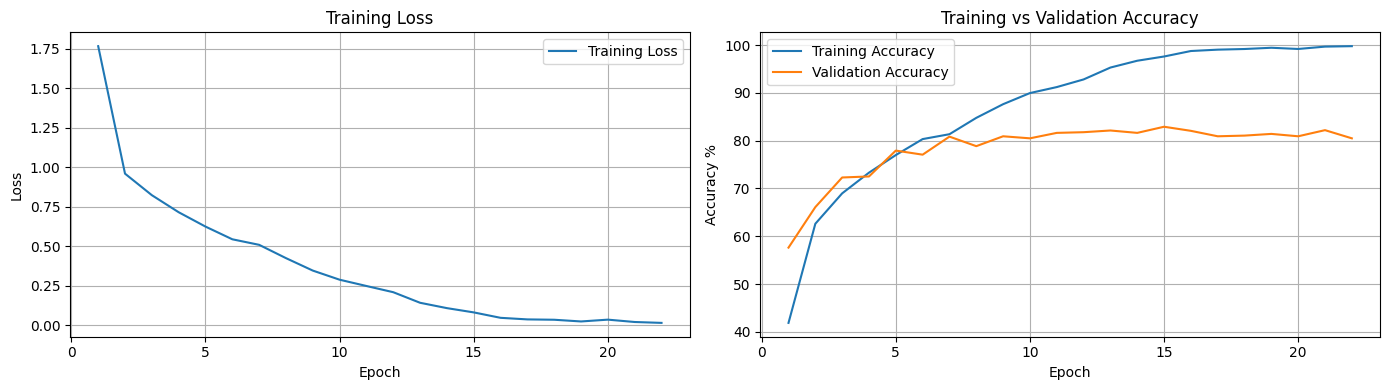

In [42]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# loss plot
ax1.plot(epochs, losses, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)
ax1.legend()

# accuracy plot
ax2.plot(epochs, [a*100 for a in training_accuracies], label='Training Accuracy')
ax2.plot(epochs, [a*100 for a in val_accuracies], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.set_title('Training vs Validation Accuracy')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [43]:
# Reclassification accuracy
y_train_true, y_train_pred = [], []
for dX, dy in training_dl:
    y_train_true += dy.tolist()
    with torch.no_grad():
        y_train_pred += cnn4.predict(dX).tolist()
print(f'Training Accuracy: {accuracy_score(y_train_true, y_train_pred)*100:.2f}%')

# Test accuracy
y_test_true, y_test_pred = [], []
for dX, dy in testing_dl:  # ← testing_dl here
    y_test_true += dy.tolist()
    with torch.no_grad():
        y_test_pred += cnn4.predict(dX).tolist()
print(f'Testing Accuracy: {accuracy_score(y_test_true, y_test_pred)*100:.2f}%')

Training Accuracy: 97.24%
Testing Accuracy: 80.90%


Part 3: Add batch normalization and early stopping features to the pipeline and 
demonstrate their effectiveness. 


Batch normalization on first block, 40 epochs, 10% Dropout, Adam optimizier, Patience 7, validation based stopping:
Epoch 19/40, Loss: 0.1375, Train Acc: 95.19%, Val Acc: 78.13%, Patience: 7/7
Early stopping at epoch 19 — val accuracy did not improve for 7 epochs
Training Accuracy: 89.60%
Testing Accuracy: 78.17%

Batch normalization on first two blocks, 40 epochs, 10% dropout, Adam optimizaer, Patience 7, validation based stopping:
Epoch 24/40, Loss: 0.0976, Train Acc: 96.58%, Val Acc: 78.42%, Patience: 7/7
Training Accuracy: 96.17%
Testing Accuracy: 82.70%

Batch normalization on first two blocks + early stopping, 10% dropout, Adam optimizer, 40 epochs, min_delta 0.001, loss based early stopping:
Epoch 26/40, Loss: 0.07  , Accuracy: 97.83%
Early stop at Epoch 26
Training Accuracy: 98.96%
Testing Accuracy: 73.60%

Batch normalization on frist block + early stopping, 20% dropout, Adam optimizer, set for 20 epochs, min_delta 0.01, loss based early stopping:
Epoch 20/20, Loss: 0.08  , Accuracy: 97.49%
Training Accuracy: 98.84%
Testing Accuracy: 78.63%

Batch normalization on first block + early stopping, 20% dropout, Adam optimizer, 40 epochs, min_delta 0.001, loss based early stopping:
Epoch 26/40, Loss: 0.04  , Accuracy: 98.65%
Early stopping at epoch 26 due to no improvement in training loss for 3 consecutive epochs.
Training Accuracy: 99.24%
Testing Accuracy: 73.43%

Batch normalization on first block, 10/10 Epochs, 20% dropout with Adam optimizer:
Epoch 10/10, Loss: 0.19  , Accuracy: 94.87%
Training Accuracy: 94.99%
Testing Accuracy: 76.83%

Batch normalization on first two blocks, 10/10 Epochs, 20% dropout with Adam optimizer:
Epoch 10/10, Loss: 0.23  , Accuracy: 91.45% 
Training Accuracy: 94.25%
Testing Accuracy: 83.43%

Batch nmormalization on all three blocks, 10/10 Epochs, 20% dropout with Adam:
Epoch 10/10, Loss: 0.20  , Accuracy: 95.73%
Training Accuracy: 97.26%
Testing Accuracy: 82.10%

Validation based stopping, no batch normalization, 20% dropout, Adam optimizer:
Epoch 20/40, Loss: 0.0681, Train Acc: 97.61%, Val Acc: 79.77%, Patience: 7/7
Training Accuracy: 94.67%
Testing Accuracy: 80.30%

Validation based stopping, no batch normalization, 10% dropout, Adam optimizer:
Epoch 22/40, Loss: 0.0138, Train Acc: 99.76%, Val Acc: 80.48%, Patience: 7/7
Training Accuracy: 97.24%
Testing Accuracy: 80.90%

I tried quite a few permutations with different methods for early stopping and incorporation of batch normalization. After batch normalization 
I was able to decrease the overfitting of the model and make the model more robust with early stopping by looking at validation scores rather than the loss parameter.
While computationally it does add a bit, the increase in performance is worth it. Loss based early stopping however always hurt results and in this case the cost of validation based stopping is worth the additional computational time. With Batch normalization, validation based early stopping is necessary, loss based early stopping will still allow the model to memorize and hurt generalization.

